In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [22]:
data = pd.read_csv('/kaggle/input/datasets/devansodariya/student-performance-data/student_data.csv')

data.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [23]:
print("Shape of Dataset:", data.shape)

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())

Shape of Dataset: (395, 33)

Data Types:
school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

Missing Values:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures   

In [24]:
data.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [41]:
data.groupby('sex')['G3'].mean()

sex
F     9.966346
M    10.914439
Name: G3, dtype: float64

In [43]:
corr = data.corr(numeric_only=True)

corr['G3'].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
Name: G3, dtype: float64

In [44]:
zero_grades = data[data['G3'] == 0]
print(f"Number of students scoring zero: {len(zero_grades)}")
zero_grades[['absences', 'failures', 'studytime', 'G1', 'G2']].describe()

Number of students scoring zero: 38


,absences,failures,studytime,G1,G2
count,38.0,38.000000,38.000000,38.000000,38.000000
mean,0.0,0.921053,1.973684,7.526316,4.657895
std,0.0,1.075063,0.914946,1.811925,3.700083
min,0.0,0.000000,1.000000,4.000000,0.000000
25%,0.0,0.000000,1.000000,6.000000,0.000000
50%,0.0,1.000000,2.000000,7.000000,5.000000
75%,0.0,1.750000,2.000000,9.000000,8.000000
max,0.0,3.000000,4.000000,12.000000,10.000000


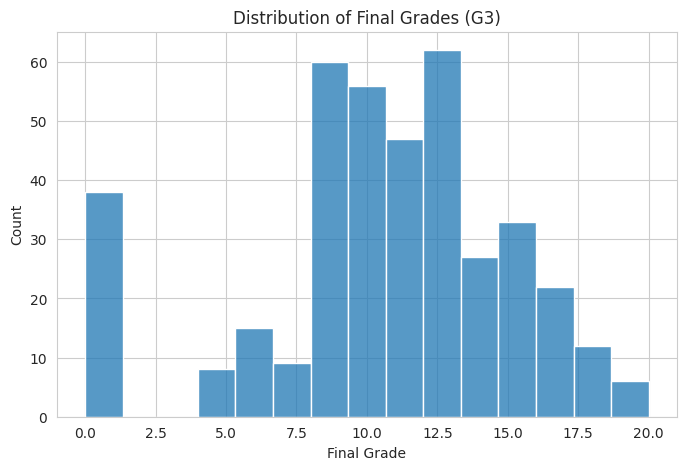

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(data['G3'], bins=15)

plt.title("Distribution of Final Grades (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Count")

plt.show()

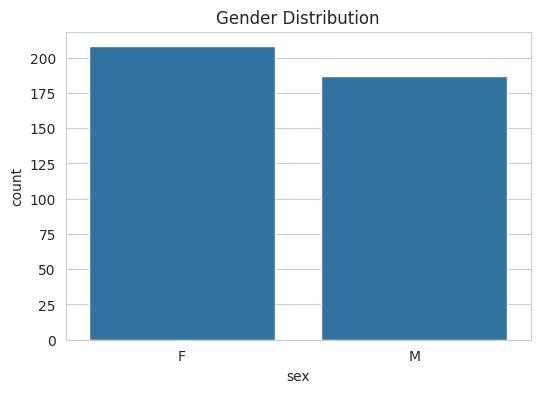

In [26]:
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=data)

plt.title("Gender Distribution")

plt.show()

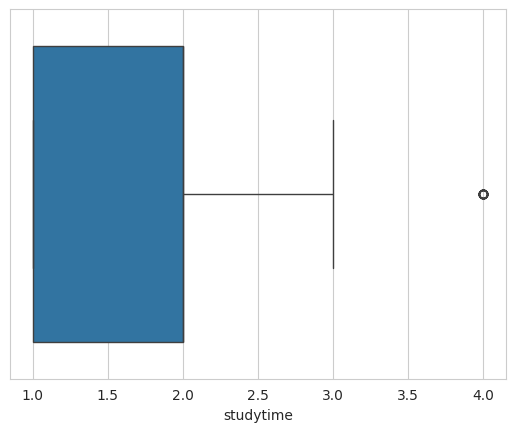

In [27]:
sns.boxplot(x=data['studytime'])
plt.show()

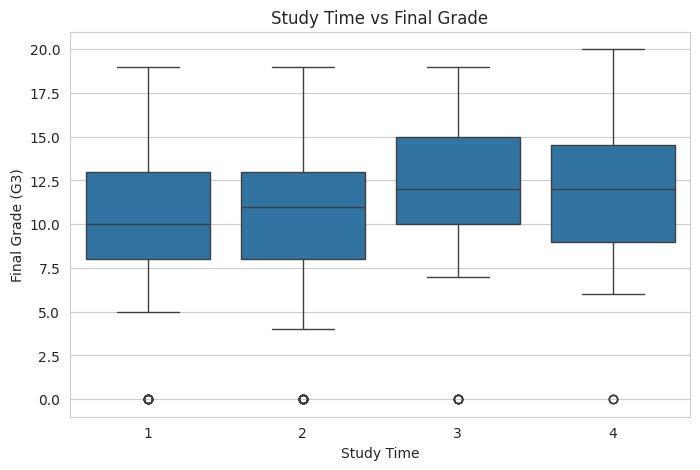

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(x='studytime', y='G3', data=data)

plt.title('Study Time vs Final Grade')
plt.xlabel('Study Time')
plt.ylabel('Final Grade (G3)')

plt.show()

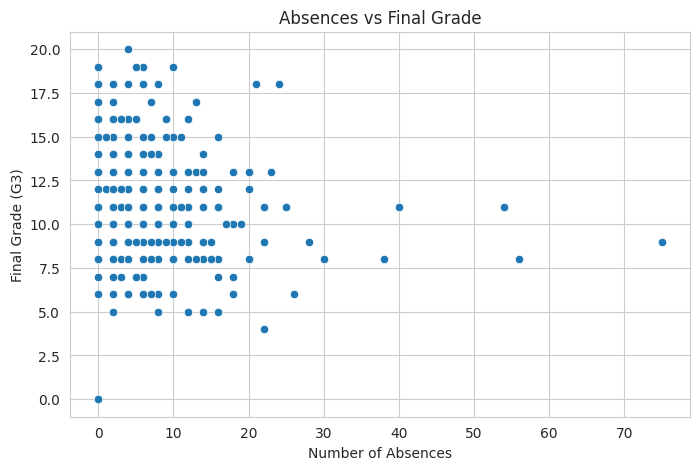

In [47]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='absences', y='G3', data=data)
plt.title('Absences vs Final Grade')
plt.xlabel('Number of Absences')
plt.ylabel('Final Grade (G3)')
plt.show()

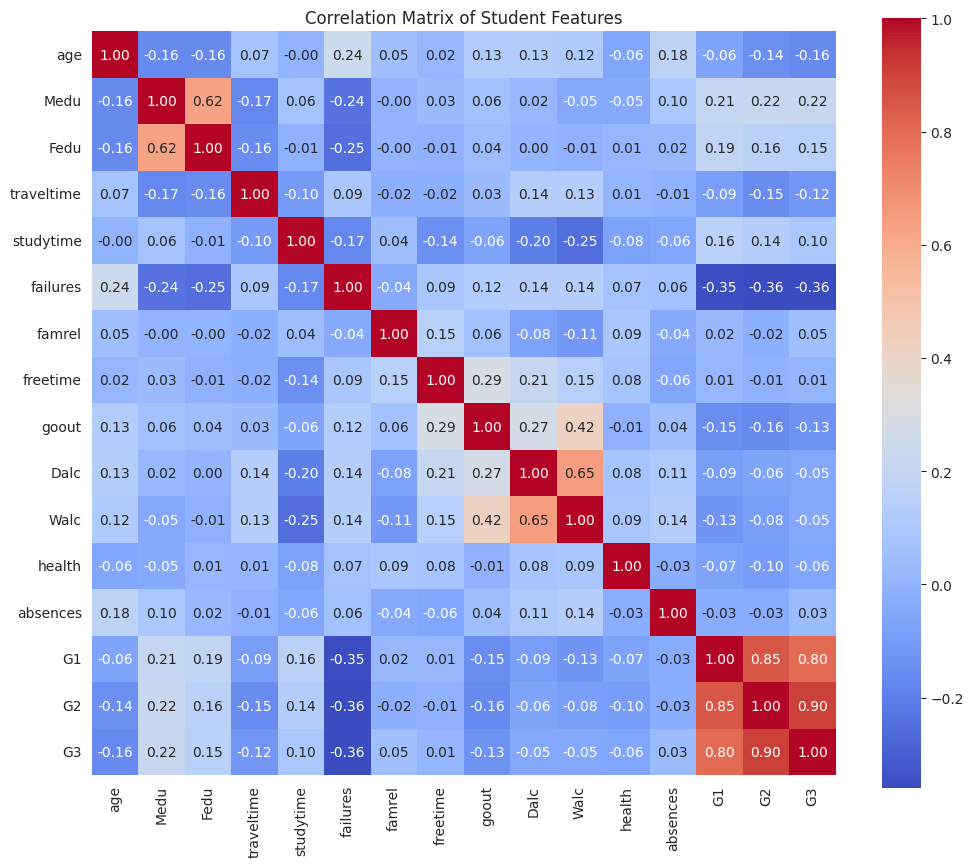

In [46]:
numerical_data = data.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numerical_data.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Correlation Matrix of Student Features')
plt.show()

/tmp/ipykernel_58/658486287.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='internet', y='G3', data=data, palette='Set2')


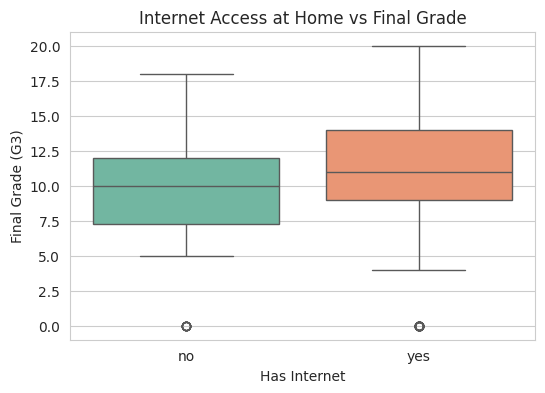

In [33]:
plt.figure(figsize=(6, 4))
sns.boxplot(x='internet', y='G3', data=data, palette='Set2')
plt.title('Internet Access at Home vs Final Grade')
plt.xlabel('Has Internet')
plt.ylabel('Final Grade (G3)')
plt.show()

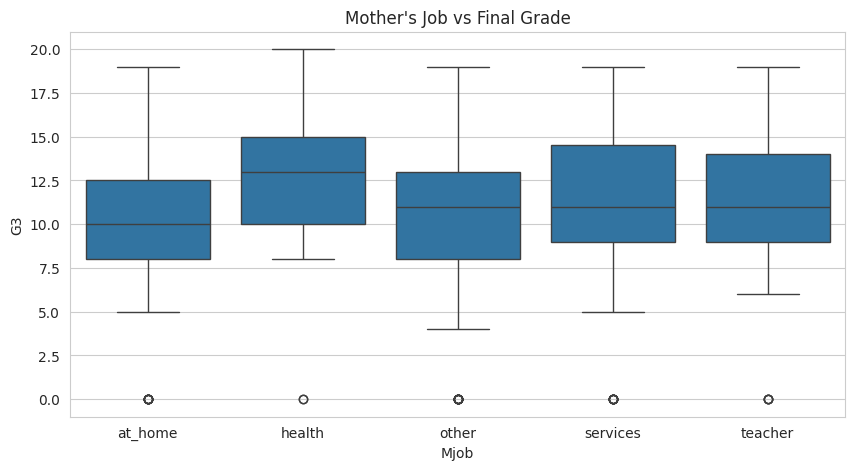

In [34]:
plt.figure(figsize=(10, 5))
sns.boxplot(x='Mjob', y='G3', data=data)
plt.title("Mother's Job vs Final Grade")
plt.show()

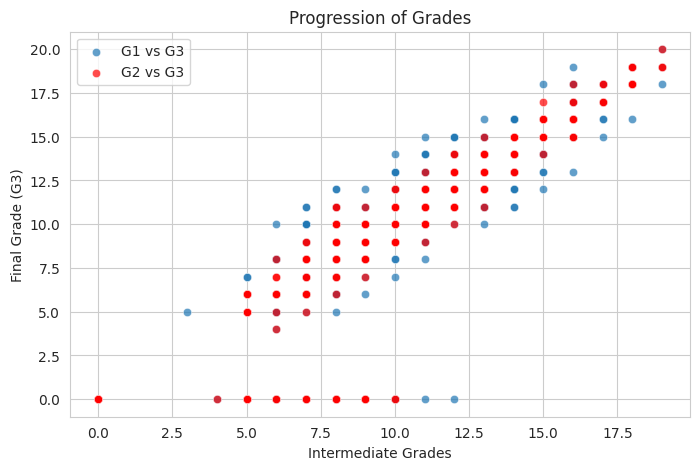

In [35]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='G1', y='G3', data=data, alpha=0.7, label='G1 vs G3')
sns.scatterplot(x='G2', y='G3', data=data, alpha=0.7, label='G2 vs G3', color='red')
plt.title('Progression of Grades')
plt.xlabel('Intermediate Grades')
plt.ylabel('Final Grade (G3)')
plt.legend()
plt.show()